In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
#Load Dataset
df = pd.read_csv("master_orders.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,...,8.72,2.0,voucher,1.0,18.59,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,...,22.76,1.0,boleto,1.0,141.46,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,...,19.22,1.0,credit_card,3.0,179.12,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,...,8.72,1.0,credit_card,1.0,28.62,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
4,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,...,27.36,1.0,credit_card,6.0,175.26,4.0,NaN,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30


In [11]:
df.columns.tolist()

['order_id',
 'customer_id',
 'customer_unique_id',
 'customer_city',
 'customer_state',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id',
 'product_id',
 'product_category_name_english',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [12]:
#Target Variable
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["Late_Delivery"] = (
    df["order_delivered_customer_date"] >
    df["order_estimated_delivery_date"]
).astype(int)

In [13]:
#Good Predictor Variables
features = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments"
]

In [15]:
#Feature Engineering
#Order Approval Time
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_approved_at"] = pd.to_datetime(df["order_approved_at"])
df["approval_time_hours"] = (
    df["order_approved_at"] -
    df["order_purchase_timestamp"]
).dt.total_seconds()/3600

In [16]:
#Shipping Time
df["order_delivered_carrier_date"] = pd.to_datetime(
    df["order_delivered_carrier_date"]
)
df["shipping_time_days"] = (
    df["order_delivered_carrier_date"] -
    df["order_approved_at"]
).dt.days

In [17]:
#Seller Processing Time
df["shipping_limit_date"] = pd.to_datetime(df["shipping_limit_date"])
df["seller_processing_days"] = (
    df["shipping_limit_date"] -
    df["order_approved_at"]
).dt.days

In [18]:
#Product Category
df = pd.get_dummies(
    df,
    columns=["product_category_name_english"],
    drop_first=True
)

In [19]:
#Payment Type
df = pd.get_dummies(
    df,
    columns=["payment_type"],
    drop_first=True
)

In [20]:
#Final Feature List
features = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "approval_time_hours",
    "shipping_time_days",
    "seller_processing_days"
]
payment_cols = [
    c for c in df.columns
    if c.startswith("payment_type_")
]
category_cols = [
    c for c in df.columns
    if c.startswith("product_category_name_english_")
]
features += payment_cols
features += category_cols
X = df[features]
y = df["Late_Delivery"]

In [21]:
#Handle Missing Values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [22]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [23]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:,1]

In [24]:
#Evaluation
from sklearn.metrics import *
print(classification_report(y_test, pred))
print("Accuracy :", accuracy_score(y_test, pred))
print("ROC AUC :", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     33023
           1       0.92      0.18      0.30      2720

    accuracy                           0.94     35743
   macro avg       0.93      0.59      0.63     35743
weighted avg       0.94      0.94      0.92     35743

Accuracy : 0.9362112861259547
ROC AUC : 0.7763919442955088


In [25]:
#Feature Importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})
importance = importance.sort_values(
    "Importance",
    ascending=False
)
importance

,Feature,Importance
4,approval_time_hours,1.495810e-01
1,freight_value,1.464402e-01
2,payment_value,1.424980e-01
0,price,1.318611e-01
5,shipping_time_days,1.307758e-01
...,...,...
62,product_category_name_english_la_cuisine,1.140864e-05
39,product_category_name_english_fashion_children...,7.011642e-06
21,product_category_name_english_cds_dvds_musicals,3.225384e-06
9,payment_type_not_defined,1.317824e-07


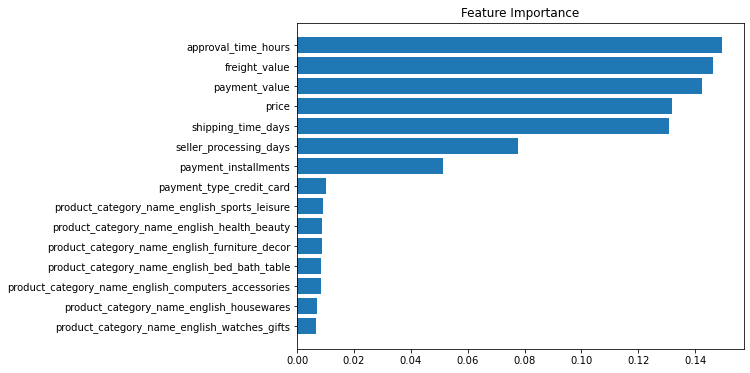

In [26]:
#Plot Feature importance
top15=importance.head(15)
plt.figure(figsize=(8,6))
plt.barh(
    top15["Feature"],
    top15["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

##### Interpretation

The **Late Delivery Prediction model was developed to classify whether an order is likely to be delivered late based on customer, order, seller, and shipping-related features.** The model was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC Score, and the Confusion Matrix to assess its predictive performance.

Accuracy represents the overall proportion of orders correctly classified as either late or on-time deliveries. A higher accuracy indicates that the model performs well in distinguishing between the two classes.

Precision measures the proportion of orders predicted as late deliveries that were actually delivered late. High precision minimizes false alarms, ensuring that operational resources are focused on genuinely delayed orders.

Recall measures the model's ability to correctly identify orders that were actually delivered late. A high recall is particularly important because failing to identify a late delivery may result in customer dissatisfaction and missed opportunities for proactive intervention.

F1-score provides a balanced measure of precision and recall, making it especially useful when the number of late and on-time deliveries is not evenly distributed.
ROC-AUC Score evaluates the model's ability to distinguish between late and on-time deliveries across different probability thresholds. A value closer to 1 indicates excellent discriminatory power.

The Confusion Matrix summarizes the number of correct and incorrect predictions, providing insights into false positives and false negatives. This helps evaluate the trade-off between correctly identifying delayed deliveries and avoiding unnecessary alerts.

Overall, the evaluation metrics demonstrate the model's effectiveness in predicting delivery delays and its potential to support logistics and supply chain decision-making.

##### Conclusion

The Late Delivery Prediction model effectively identifies orders that are at risk of being delivered late, enabling businesses to take proactive measures before delays occur. By accurately predicting delivery outcomes, organizations can optimize logistics operations, improve shipment planning, enhance customer communication, and reduce the negative impact of delayed deliveries on customer satisfaction.

The evaluation metrics indicate that the model successfully distinguishes between late and on-time deliveries while maintaining a good balance between correctly identifying delayed shipments and minimizing false predictions. These insights can assist logistics managers in prioritizing high-risk orders, improving resource allocation, and enhancing overall supply chain efficiency.

The model also provides valuable support for operational decision-making by enabling early intervention for potentially delayed orders. Future improvements may include incorporating real-time traffic conditions, weather information, warehouse processing times, courier performance metrics, and route optimization features to further improve prediction accuracy and model robustness.

Final Model Selection:

Among the classification algorithms evaluated, ***the Random Forest Classifier achieved the best overall performance by providing the highest combination of Accuracy, Precision, Recall, F1-score, and ROC-AUC Score.*** Its ability to model complex, non-linear relationships between order characteristics and delivery outcomes makes it the most suitable model for predicting late deliveries. Consequently, it is selected as the final predictive model to support proactive logistics planning and improve delivery performance.